<a href="https://colab.research.google.com/github/juand019/ml2026/blob/main/MetodiAI_2026_E2_python_numpy_classificatoreNaiveBayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metodi AI per La Fisica 2026

## Esercitazione E2: python e uso librerie numpy, matplotlib

**Task:**

1. familiarizzare con numpy e matplotlib

2. implementare un fitter lineare con numpy/python

3. implementare senza fare uso di librerie dedicate di Machine Learning un semplice algoritmo di classificazione basato sulla stima delle densità di probabilità delle feature discriminanti (*Classificatore Naive di Bayes*)

**Parte 0:**

Giochiamo con numpy:

In [2]:
# lista python vs array numpy

import numpy as np  #import della libereria numpy associandogli come namespace l'acronimo "np" (eg. le funzioni di numpy verranno chiamate come np.xxxx )

# creo un vettore di dimensione "dim" usando una lista python

dim = 10
lista_python = list(range(dim))

# creo un array numpy di dimensione "dim"

array_numpy = np.arange(dim)  #la funzione np.arange rappresenta l'equivalente numpy di range di python

print(lista_python)
print('')
print(array_numpy.shape) #stampa le dimensioni di un array numpy
print('')
print(array_numpy)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

(10,)

[0 1 2 3 4 5 6 7 8 9]


In [3]:
# confrontiamo i tempi necessari per fare una semplice operazione sul vettore rappresentato come lista python e come array numpy

dim = 100000
lista_python = list(range(dim))
array_numpy = np.arange(dim)

%timeit lista_python_2 = [x * 2 for x in lista_python]   #il modulo timeit di python permette du misurare il tempo di esecuzione di semplici parti di codice python

%timeit array_numpy_2 = array_numpy * 2

print('numpy è tipicamente ~100 volte pìu veloce di vanilla python')

3.71 ms ± 107 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)
80.8 µs ± 12.7 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)
numpy è tipicamente ~100 volte pìu veloce di vanilla python


In [ ]:
# un array multidimensionale in numpy

array2 = np.ones(shape=(100,10,10))  #np.ones crea un arry con tutti gli elementi inizializzati a 1 (np.zeros a zero, np.empty non inizalizza i valori, np.full inizializza al valore indicato)
array2int = np.ones(shape=(100,10,10),dtype='int32')
array3 = np.full(shape=(100,10,10), fill_value=33.0)

print(array2.shape,'\n')
print(array2.dtype,'\n')
print(array2int.dtype,'\n')
print(array2[:2,:,:],'\n') # array[a:b] seleziona gli elementi da a a b-1 dell'array ([:] equivale all'intero array)
print(array2int[:2,:,:],'\n')
print(array3[:2,:,:],'\n')

(100, 10, 10) 

float64 

int32 

[[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]

 [[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]] 

[[[1 1 1 1 1 1 1 1 1 1]
  [1 1 1 1 1 1 1 1 1 1]
  [1 1 1 1 1 1 1 1 1 1]
  [1 1 1 1 1 1 1 1 1 1]
  [1 1 1 1 1 1 1 1 1 1]
  [1 1 1 1 1 1 1 1 1 1]
  [1 1 1 1 1 1 1 1 1 1]
  [1 1 1 1 1 1 1 1 1 1]
  [1 1 1 1 1 1 1 1 1 1]
  [1 1 1 1 1 1 1 1 1 1]]

 [[1 1 1 1 1 1 1 1 1 1]
  [1 1 1 1 1 1

**Esercizio:**


dati i seguenti oggetti, rappresentarli con numpy:

*   scalare: $s = 12.3$   
*   vettore: $v = \left[ 3.0, -2.0, 5.5 \right]$
*   matrice: $M = \left[
\begin{array}{ccc}
  5.0 & 0.8 & -0.2 \\
-0.8 & 3.0 & -0.8 \\
0.2 & 0.8 & 1.0
\end{array}
\right]
$


e calcolare i valori di:

1.   $y = v+v$
2.   $y = sv$
2.   $y = v\cdot v$
3.   $y = Mv$
4.   $Y = M^2$



In [11]:
s = 12.3
v = np.array([3.0, -2.0, 5.5])
M = np.array([[5, 0.8, -0.2], [-0.8, 3, -0.8], [0.2, 0.8, 1]])
print(s, '\n', v, '\n', M)
y0 = v+v
y1 = s*v
y2 = np.dot(v, v)
y3 = np.dot(M, v)
Y = np.dot(M, M)
print(y0, '\n', y1, '\n', y2, '\n', y3, '\n', Y)

12.3 
 [ 3.  -2.   5.5] 
 [[ 5.   0.8 -0.2]
 [-0.8  3.  -0.8]
 [ 0.2  0.8  1. ]]
[ 6. -4. 11.] 
 [ 36.9  -24.6   67.65] 
 43.25 
 [ 12.3 -12.8   4.5] 
 [[24.32  6.24 -1.84]
 [-6.56  7.72 -3.04]
 [ 0.56  3.36  0.32]]


In [12]:
#@title Soluzione

import numpy as np

s1 = 12.3
v1 = np.array([3.0,-2.0,5.5])
M1 = np.array([5.0, 0.8, -0.2, -0.8, 3.0, -0.8, 0.2, 0.8,  1.0])
M1 = np.reshape(M1, (3,3))

y1 = v1+v1
y2 = s1*v1
y3 = np.dot(v1,v1)
y4 = np.dot(M1,v1)
y5 = np.dot(M1,M1)

print('v+v = ', y1)
print('')
print('sv = ', y2)
print('')
print('v . v = ', y3)
print('')
print('Mv = ', y4)
print('')
print('M^2 = \n', y5)

v+v =  [ 6. -4. 11.]

sv =  [ 36.9  -24.6   67.65]

v . v =  43.25

Mv =  [ 12.3 -12.8   4.5]

M^2 = 
 [[24.32  6.24 -1.84]
 [-6.56  7.72 -3.04]
 [ 0.56  3.36  0.32]]


In [13]:
# generazione di numeri random con numpy

# numpy contiene una libreria di generatori di numeri random molto ampia (più o meno tutte le distribuzioni note)

gaussian_array = np.random.normal(loc=4.0, scale=2.0, size=(100))  #array di dimensione (100) contenente numeri gaussiani random con mu=loc, sigma=scale

uniform_array = np.random.uniform(low=0.,high=22.0, size=(10,10)) #array di dimensione (10,10) contenente numeri uniformi random tra low e high

print(gaussian_array[:10],'\n')
print(uniform_array[0,:],'\n')

[6.80086633 2.15543753 5.39354134 1.74837965 5.39243651 3.16294982
 1.97492752 1.03829632 2.96388827 4.94882026] 

[ 8.17939002  4.27284182 11.23977187  4.48647468 20.50589784  7.23560434
 18.71146048 21.22088977 19.70846159 14.37751122] 



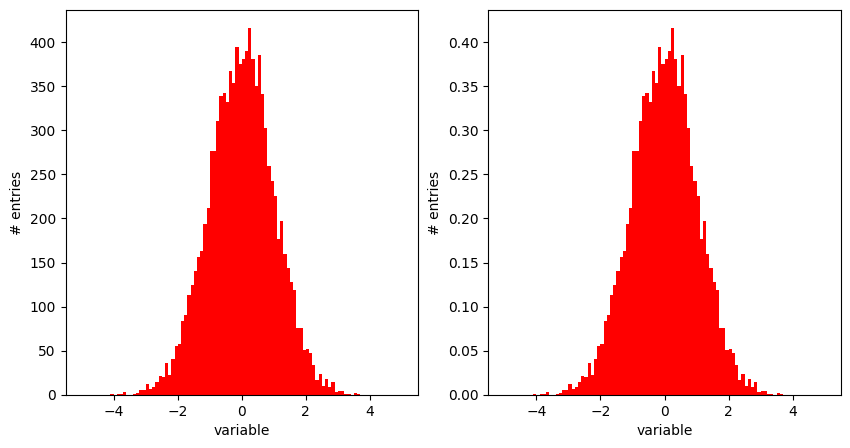

In [8]:
# histogramma in matplotlib contenente la distribuzione generata da numpy
import matplotlib.pyplot as plt #importa il modulo pyplot di matplotlib (un sottoset di tool di alto livello per produrre i plot più utilizzati)

gaussian_array2 = np.random.normal(loc=0.0, scale=1.0, size=(10000))

# un plot con due figure
plt.figure(figsize=(10,5))
plt.subplot(1, 2, 1) # 2 sub-plot sulla stessa riga, posizione 1
n, bins, _ = plt.hist(gaussian_array2, bins=100, range=[-5.,5.], color='red', density=False, cumulative=False)
plt.xlabel('variable')
plt.ylabel('# entries')

plt.subplot(1, 2, 2) # 2 sub-plot sulla stessa riga, posizione 2
n, bins, _ = plt.hist(gaussian_array2, bins=100, range=[-5.,5.], color='red', density=True, cumulative=False)
plt.xlabel('variable')
plt.ylabel('# entries')

plt.show()

**Esercizio 1: provare ad implementare un'algoritmo basilare di regressione lineare**

1.   viene dato il seguente dataset di coppie di misure $T\{x_i,y_i\}, i=1,\cdots N$:



```
x = [0., 2.22, 4.44, 6.67, 8.89, 11.11, 13.33, 15.56, 17.788, 20.0]

y = [-2.1489976, 1.26684956, 5.00441023, 3.84220594, 5.95983884, 6.44189515,
  6.88238407, 12.04053287, 10.73255652, 10.29414663]
```

2.  si ipotizza che il campione sia stato prodotto in accordo ad una funzione lineare del tipo: $y = w x + \epsilon\,,\quad \epsilon\sim N(0,\sigma)$, in cui $x\in\mathbb{R}$ rappresenta l'input, $w=0.6$, e $y\in\mathbb{R}$ le osservazioni "rumorose" ($\epsilon$ è un numero random gaussiano estratto evento per evento)

3. si deve scrivere ed allenare un modello lineare di ML che apprenda la funzione di mapping $y=f_w(x)$, addestrando l'algoritmo in modo empirico in base a $k$ step di addestramento, in cui, partendo da un valore random del parametro $w$ nell'intervallo $(0,1)$, si aggiorni il valore di $w$ ad ogni step muovendosi in un intervallo piccolo intorno al valore corrente del paramento, e accettando la nuova soluzione in accordo alla funzione di costo Mean Squared Error: $MSE$ definita come: $MSE(w) = \frac{1}{N}\sum_{i=1}^N (y_i - f_w(x_i))^2$, in cui la somma è fatta su gli elementi del dataset.


```
# per generare numeri pesudorandom in python
# import xxxx, importa la libreria python xxxx

import random

a = random.random()
print(a)
```



3.   testare le predizioni del modello con input $x \in [0.,20.]$ e confrontare con l'andamento teorico ipotizzato ($w = 0.6$), calcolando l'MSE tra risultati predetti e quelli veri attesi assumendo $w=0.6$.

4.   guardare alla soluzione proposta per vedere come è possibile graficare in un plot $y$ VS $x$, i risultati ottenuti, sfruttando la libreraia python **matplotlib** (che vedremo più in dettaglio nella prossima lezione).

epoch  0  improved loss: mse / w_star: 3.175149276387952  /  0.6877354831459921
epoch  1  improved loss: mse / w_star: 2.712029282067628  /  0.6647991751876441
epoch  4  improved loss: mse / w_star: 2.361679979126129  /  0.6383302396776651
epoch  6  improved loss: mse / w_star: 2.21999786922857  /  0.5929620661038703
epoch  21  improved loss: mse / w_star: 2.2024269627475705  /  0.6014597797144944
epoch  38  improved loss: mse / w_star: 2.2014998990347854  /  0.6028245810818362
best model loss =  2.2014998990347854  per w_star =  0.6028245810818362 

[ 0.          1.05263158  2.10526316  3.15789474  4.21052632  5.26315789
  6.31578947  7.36842105  8.42105263  9.47368421 10.52631579 11.57894737
 12.63157895 13.68421053 14.73684211 15.78947368 16.84210526 17.89473684
 18.94736842 20.        ]
MSE test set:  0.0010917616604449987


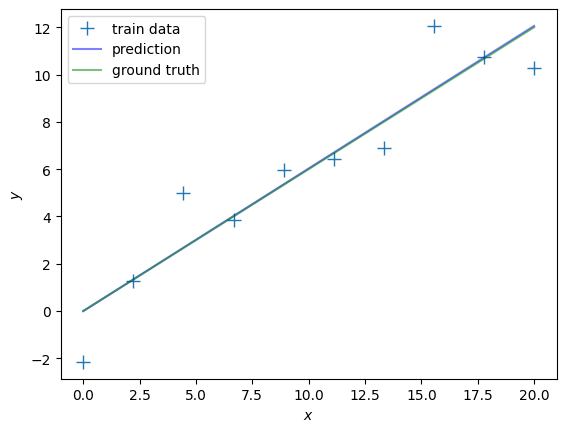

In [27]:
# codice
import random
import numpy as np
import matplotlib.pyplot as plt


x = [0., 2.22, 4.44, 6.67, 8.89, 11.11, 13.33, 15.56, 17.788, 20.0]

y = [-2.1489976, 1.26684956, 5.00441023, 3.84220594, 5.95983884, 6.44189515,
  6.88238407, 12.04053287, 10.73255652, 10.29414663]

w = 0.6
w_i = random.random()

# i theorise a model of the sort y = w*x, where w is an unkown parameter i want to estimate, iterating and improving the estimate
def model(w, x):
  return w*x

# here i define a loss function that calculates the mean squared error at each point (x, y)
# using the difference of the actual data points (x, y)
# and the theorised linear estimate modeled using the estimated parameter w
# this difference gets added and divided by the number of data points
def mse_loss(x, y, w):
  loss = 0.0
  for item in range(len(x)):
    loss += (y[item] - model(w, x[item]))**2.0
  return loss/len(x)

# here i run the loss function with an initial random estimate for w
loss_i = mse_loss(x, y, w_i)

# here i define how many iterations (cycles of estimating and correcting the estimate) k
# and how much (eta) i will deviate from the previous estimate each cycle
k = 50
eta = 0.1

# update the estimated w, modifying it by a small step (multiplied by the eta)
# and repeat for the number of cycles k
for epoch in range(k):
  step = 2*random.random() - 1
  w_new = w_i + eta*step
  # calculate the loss for the new w estimate
  loss = mse_loss(x, y, w_new)

  # if the new loss is less than the previous one, update w to use the better suited one
  if loss < loss_i:
    loss_i = loss
    w_i = w_new
    print('epoch ', epoch, ' improved loss: mse / w_star:', loss_i, ' / ', w_i)

print('best model loss = ', mse_loss(x,y,w_i), ' per w_star = ', w_i, '\n')

# now test the new w by defining a new set of x and its corresponding y
# test it by comparing the function using the true w vs the function using the estimated function

x_test = np.linspace(0, 20, 20)
print(x_test)
y_true = model(w, x_test)
y_est = model(w_i, x_test)

# calculate loss from real vs estimated functions
loss_test = mse_loss(x_test, y_true, w_i)
print('MSE test set: ', loss_test)

plt.figure()
plt.plot(x, y, '+', markersize=10, label='train data')
plt.plot(x_test, y_est, color='blue', alpha=0.5, label='prediction')
plt.plot(x_test, y_true, color='green', alpha=0.5, label='ground truth')
plt.xlabel("$x$")
plt.ylabel("$y$");
plt.legend()
plt.draw()





epoch  3  improved loss: mse / w_star: 7.01411720445667  /  0.7894549530348702
epoch  5  improved loss: mse / w_star: 3.9726921935547055  /  0.7167338900879225
epoch  6  improved loss: mse / w_star: 2.520416592771182  /  0.6521816751589418
epoch  8  improved loss: mse / w_star: 2.321795834444414  /  0.6338374787722776
epoch  11  improved loss: mse / w_star: 2.2309761694804826  /  0.5899817559194686
epoch  12  improved loss: mse / w_star: 2.2233535158678035  /  0.5919759425287799
epoch  17  improved loss: mse / w_star: 2.2034836210759243  /  0.6086879579772528
best model loss =  2.2034836210759243  per w_star =  0.6086879579772528 

MSE test set:  0.009321855806092173


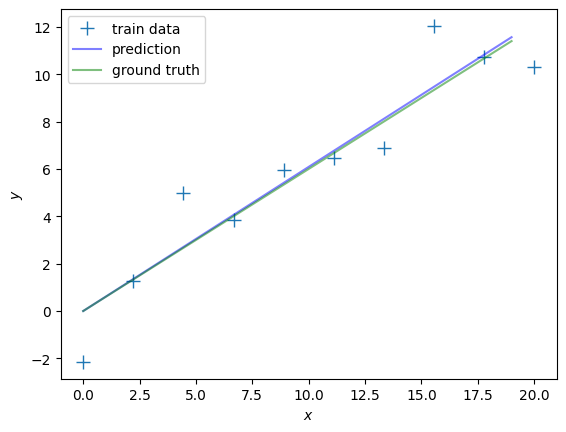

In [22]:
#@title Soluzione

# creo due liste contenenti i dati del camppione di training:
x_train = [0., 2.22, 4.44, 6.67, 8.89, 11.11, 13.33, 15.56, 17.788, 20.0]

y_train = [-2.1489976, 1.26684956, 5.00441023, 3.84220594, 5.95983884, 6.44189515,
  6.88238407, 12.04053287, 10.73255652, 10.29414663]

# creo una funzione che implementa il modello lineare
def model(x, w):
  return w*x

# creo una funzione che implementa la loss MSE
# input sono due liste (x, y) e il valore del parametro w
def mse_loss(x, y, w):
  res = 0.0
  for event in range(len(x)):
    res += (y[event]-model(x[event],w))**2.0
  return res/len(x)


# training del modello con il campione di training

k = 50 #step di addestramento
eta = 0.1 #learning rate

import random
w_star = random.random() #inizializzo in modo random in (0,1) il parametro da addestrare
loss_old = mse_loss(x_train,y_train,w_star) # loss iniziale

for epoch in range(k):

  # mi sposto nel loss landscape di una quantità eta*step con step un numero random in (-1,1)
  step = 2*random.random() - 1
  w_new = w_star + eta*step

  # nuova loss
  loss_new = mse_loss(x_train,y_train,w_new)

  # se loss_new < loss_old aggiorno w
  if loss_new < loss_old:
    w_star = w_new
    loss_old = loss_new
    print('epoch ',epoch, ' improved loss: mse / w_star:', loss_new, ' / ', w_star)

print('best model loss = ', mse_loss(x_train,y_train,w_star), ' per w_star = ', w_star, '\n')

# test set
x_test = list(range(20)) #creo una lista con 20 valori equispaziati tra 0 e 20
y_true = list([model(x_test[ev], 0.6) for ev in range(20)])  # ground truth
y_pred = list([model(x_test[ev], w_star) for ev in range(20)]) #risultati predetti sul test set


# calcolo mse
mse_test = mse_loss(x_test, y_true, w_star)
print('MSE test set: ', mse_test)


# plot dei risultati usando io modulo pyplot della libreria matplotlib
import matplotlib.pyplot as plt

plt.figure()
plt.plot(x_train, y_train, '+', markersize=10, label='train data')
plt.plot(x_test, y_pred, color='blue', alpha=0.5, label='prediction')
plt.plot(x_test, y_true, color='green', alpha=0.5, label='ground truth')
plt.xlabel("$x$")
plt.ylabel("$y$");
plt.legend()
plt.draw()

**Esercizio 2: Classificatore Naive Bayes**

**parte 1:**

**Generazione di un dataset "toy":**

1. generare due campioni di esempi rappresentativi di due dtribuzioni diverse: classe segnale ($S$) e classe fondo ($B$)).<p>

> Ogni esempio è descritto da un vettore di dimensione $d=3$, in cui le tre feature, $(x_0,x_1,x_2)$, sono distribuite in accordo a distribuzioni gaussiane multivariate: $f(x_0,x_1,x_2) = GaussianaMultivariata(x_0,x_1,x_2:\mu, cov)$, con $\mu$ il vettore delle medie delle tre variabili e $cov$ la matrice $3\times 3$ di covarianza (ogni dimensione corrisponde ad una feature (osservabile) del dataset). <p>

> `Suggerimento: usare la funzione numpy: np.random.multivariate_normal(mean, cov, size) in cui mean è un vettore con i valori medi delle 3 feature, e cov è la matrice 3x3 di covarianza`

> le medie delle due distribuzioni per segnale e fondo da utilizzare sono: $\mu_S = [0.0, 4.0, -1.0]$, $\mu_B = [-2.5, 2.0, 2.0]$;

> la matrice di covarianza tra le variabili è la stessa per le due classi $S$ e $B$ ed è data dalla matrice diagonale $diag[4.0, 1.0, 2.25]$;

> la dimensione dei campioni è di $N=3000$ esempi per ognuna delle due classi.

2. graficare le distribuzioni delle feature delle due classi su tre proiezioni 2D: $(x_0,x_1), (x_0,x_2), (x_1,x_2)$ colorando con colori rosso e blu i punti appartenenti agli eventi di classe $S$ e $B$ rispettivamente <p>

>`Suggerimento: usare la funzione matplotlib: plt.plot(x,y, color) in cui color='r' o 'b')`


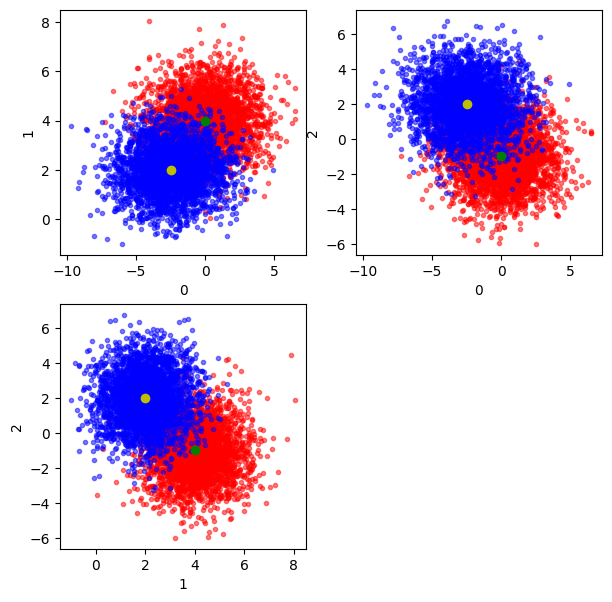

In [43]:
#code
import numpy as np
import matplotlib.pyplot as plt

N = 3000
d = 3
mu_S = np.array([0.0, 4.0, -1.0])
mu_B = np.array([-2.5, 2.0, 2.0])
cov = np.array([4.0, 0, 0, 0, 1, 0, 0, 0, 2.25])
cov = cov.reshape((d, d))
# print(cov)

S = np.random.multivariate_normal(mu_S, cov, size=N)
B = np.random.multivariate_normal(mu_B, cov, size=N)

plt.figure(figsize=(7,7))
for i in range(d):
  for j in range(d):
    if i < j:
      plt.subplot(2, 2, j+i)
      plt.plot(S[:, i], S[:, j], "r.", alpha=0.5)
      plt.plot(B[:,i], B[:, j], "b.", alpha=0.5)
      plt.plot(mu_S[i], mu_S[j], "go")
      plt.plot(mu_B[i], mu_B[j], "yo")
      plt.xlabel(i)
      plt.ylabel(j)
    else: pass




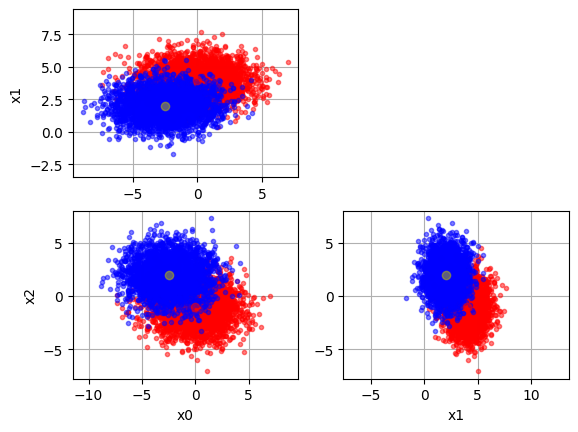

In [ ]:
#@title Soluzione Parte 1 (clicca su show code per vedere il codice)
import numpy as np
import matplotlib.pyplot as plt

# genera 3 osservabili gaussiane, correlate (x1,x2,x3)

N = 3000

# valori medi delle tre osservabili
muS = np.array([0.0, 4.0, -1.0])
muB = np.array([-2.5, 2.0, 2.0])

# matrice di covarianza
rS = np.array([
        [ 4.0, 0.0, 0.0],
        [ 0.0, 1.0, 0.0],
        [ 0.0, 0.0, 2.25]
    ])

rB = rS

#nota: a=b tra due oggetti python non crea un nuovo oggetto, a e b puntano alla stessa locazione di memoria modificando uno si modifica anche l'altro
#      se si vuole creare una copia separata (in questo caso non è necessario) si deve fare una deep copy: b = a.copy()

# Generazione usando numpy
xS = np.random.multivariate_normal(muS, rS, size=N)
xB = np.random.multivariate_normal(muB, rB, size=N)


# Plot delle diverse proiezioni
plt.subplot(2,2,1)
plt.plot(xS[:,0], xS[:,1], 'r.', alpha=0.5)
plt.plot(xB[:,0], xB[:,1], 'b.', alpha=0.5)
plt.plot(muS[0], muS[1], 'ro', alpha=0.5)
plt.plot(muB[0], muB[1], 'yo', alpha=0.5)
plt.ylabel('x1')
plt.axis('equal')
plt.grid(True)

plt.subplot(2,2,3)
plt.plot(xS[:,0], xS[:,2], 'r.', alpha=0.5)
plt.plot(xB[:,0], xB[:,2], 'b.', alpha=0.5)
plt.plot(muS[0], muS[2], 'ro', alpha=0.5)
plt.plot(muB[0], muB[2], 'yo', alpha=0.5)
plt.xlabel('x0')
plt.ylabel('x2')
plt.axis('equal')
plt.grid(True)

plt.subplot(2,2,4)
plt.plot(xS[:,1], xS[:,2], 'r.', alpha=0.5)
plt.plot(xB[:,1], xB[:,2], 'b.', alpha=0.5)
plt.plot(muS[1], muS[2], 'ro', alpha=0.5)
plt.plot(muB[1], muB[2], 'yo', alpha=0.5)
plt.xlabel('x1')
plt.axis('equal')
plt.grid(True)

plt.show()

**Parte 2:**

Stima delle funzioni di distribuzione di probabilità delle singole feature per le due classi $S$ e $B$: <p>

>$p(x_0|C),~ p(x_1|C), ~p(x_2|C)$ con $C=S,B$

Procedura:

1. costruire 3 histogrammi per ciascuna classe, con $M=20$ bin negli intervalli $(\mu-4\sigma, \mu+4\sigma)$ che contengano la distribuzione della densità di probabilità delle features $x_0,x_1,x_2$ nelle due classi. <p>

> `Suggerimento: costruire un histogramma con plt.hist e riempirlo con ciascuna feature, usando l'opzione di avere histogrammi normalizzati (density=True)`

> NOTA: usare solo i primi 2000 eventi di ogni campione per costruire gli istogrammi, lasciando i restanti 1000 come campione di test.


2. scrivere una funzione python che prende in input un valore della feature $x$, uno degli istogrammi $H$, e ritorna la stima della probabilità associata $f(x_i) = p(x_i|C)$. <p>  

>SUGGERIMENTO: la funzione *n, edges, patches = plt.hist(x,...)* di matplotlib ritorna tre array numpy: *n* contenenente il contenuto dei bin, *edges* contenente le edge (il valore della $x$ corrispondente all'estremo superiore) di ogni bin, ed il terzo non interessante per gli scopi.

> la funzione deve identificare quale è l'indice del array *edges* che contiene il valore della feature *x*, e poi prendere come stima della probabilità $p(x|C)$ il valore dell array *n* che corrisponde a quel bin

>SUGGERIMENTO: la funzione *np.where* ritorna gli elementi del vettore che soddisfano una data condizione.

3. plottare con matplotlib gli istogrammi così costruiti

In [ ]:
#codice

p(x0=4.0|S) =  0.03750000000000005
p(x0=4.0|B) =  0.0006249999999999995



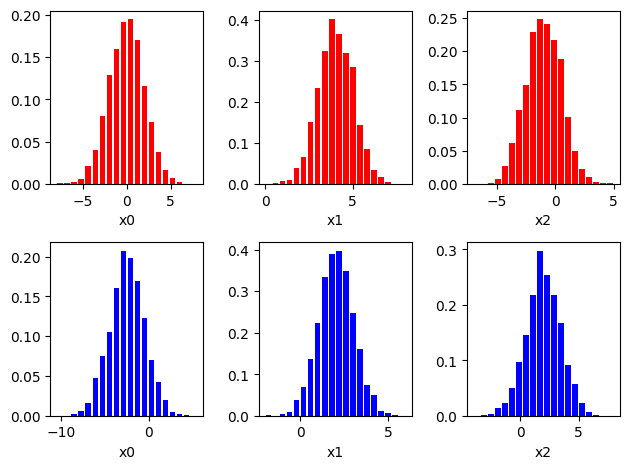

In [ ]:
#@title Soluzione Parte 2 (clicca su show code per vedere il codice)
import numpy as np
import matplotlib.pyplot as plt

pdfS = []
edgesS = []
pdfB = []
edgesB = []
for i in range(3):
  plt.subplot(2,3,i+1)
  n, edges, _ = plt.hist(xS[:2000,i], bins=20, rwidth=0.8, color='red', range=(muS[i]-4*np.sqrt(rS[i,i]),muS[i]+4*np.sqrt(rS[i,i])), density=True)
  plt.xlabel('x'+str(i))
  pdfS.append(n)
  edgesS.append(edges)
  plt.subplot(2,3,i+4)
  n, edges, _ = plt.hist(xB[:2000,i], bins=20, rwidth=0.8, color='blue', range=(muB[i]-4*np.sqrt(rB[i,i]),muB[i]+4*np.sqrt(rB[i,i])), density=True)
  plt.xlabel('x'+str(i))
  pdfB.append(n)
  edgesB.append(edges)
plt.tight_layout()

def pdf_fun(x,P,E):
  if x>E[-1]: return 0.0 #above max range (NOTA array[-1] identifica l'ultimo elemento di un array)
  res = np.where(E<x)[0] #la funzione ritorna un array(lista, ), lo [0] serve per estrarre la lista
  if np.size(res)>0:
      return P[res[-1]] #res[-1] seleziona l'ultimo elemento della lista
  return 0.0

print('p(x0=4.0|S) = ', pdf_fun(4.0, pdfS[0], edgesS[0]))
print('p(x0=4.0|B) = ', pdf_fun(4.0, pdfB[0], edgesB[0]))
print()

**Parte 3:**

Costruire un classificatore basato sul cosidetto maximum likelihood ratio (MLR). Il MLR permette di definire un discriminante statistico per gli eventi appartenenti tra due classi, tramite il rapporto tra le distribuzioni di probabilità $p(x|C)$ delle feature nelle due classi. <p>

Assumendo stesse probabilità a priori per le due classi $P(S)=P(B)$ il discriminante di MLR assume la forma:

> $\color{red}{d(x_0,x_1,x_2) = \frac{\prod_{i} p(x_i|S)}{\prod_{i}\, p(x_i|S)~+~\prod_{i}\, p(x_i|B)}}$

in cui la produttoria scorre sulle pdf delle tre features $i=1,\cdots,3$.

Quando $\prod_{i} p(x_i|S) \gg \prod_{i} p(x_i|B) \Rightarrow d\to 1$, quando $\prod_{i} p(x_i|S) \ll \prod_{i} p(x_i|B) \Rightarrow d\to 0$.

Quindi il discriminante può essere usato per classificare eventi che sono statisticamente più compatibili con la classe segnale ($d\ge0.5$), da eventi che sono più compatibili con la classe fondo ($d<0.5$).

1.    costruire la funzione discriminante $d(x_0,x_1,x_2)$;
2.    printare i valori di $d(\mu_S)$ e $d(\mu_B)$
3.    graficare un istogramma della variabile discriminante $d$ per gli eventi delle classi $S$ (colore rosso) e $B$ (colore blu);
4.    costruire una funzione che implementi la regola di classificazione: <p>
$\color{red}{d(x_0,x_1,x_2)\ge 0.5 \to \text{classe}\,S;\,\,\text{altimenti} \to \text{classe}\,B}$
5.    usando i 1000 eventi del test set che **non** sono stati utilizzati per calcolare le pdf, calcolare la cosidetta **accuracy** del classificatore, eg la frazione dei eventi per il quale il classificatore ha predetto correttamente la classe di appartenenza:

> $\color{red}{\text{Acc} = \frac{\text{# eventi correttamente classificati}}{\text{# eventi totali}}}$.

In [ ]:
#codice

d(muS) =  0.9935793423361686
d(muB) =  0.006567206988771856

Confusion matrix test:
[[929  71]
 [ 63 937]]

accuracy test set:  0.933


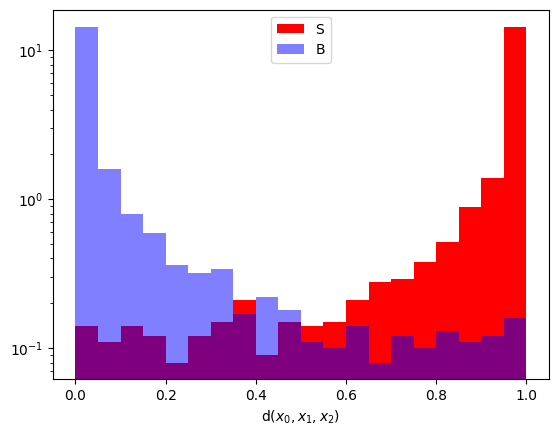

In [ ]:
#@title Soluzione Parte 3 (clicca su show code per vedere il codice)
import numpy as np
import matplotlib.pyplot as plt

#funzione discriminante di Bayes
def d(X,PS,ES,PB,EB):

  S = 1.0
  B = 1.0
  for i in range(3):
    S *= pdf_fun(X[i],PS[i],ES[i])
    B *= pdf_fun(X[i],PB[i],EB[i])
  if (S+B)>0:
    return S/(S+B)
  else:
    return 0.5

print('d(muS) = ', d(muS, pdfS,edgesS,pdfB,edgesB))
print('d(muB) = ', d(muB, pdfS,edgesS,pdfB,edgesB))

# eventi del Train Set
dS = [d(x,pdfS,edgesS,pdfB,edgesB) for x in xS[:2000]] #primi 2000 eventi
dB = [d(x,pdfS,edgesS,pdfB,edgesB) for x in xB[:2000]] #primi 2000 eventi

plt.hist(dS, bins=20, color='red', range=(0,1), density=True, label='S')
plt.xlabel('d')
plt.hist(dB, bins=20, color='blue', alpha=0.5, range=(0,1), density=True, label='B')
plt.xlabel('d($x_0,x_1,x_2$)')
plt.yscale('log')
plt.legend()
print()

# regola di classificazione
def disc(X, PS,ES,PB,EB):
  if d(X,PS,ES,PB,EB)>=0.5:
    return  1 #classe S
  else:
    return -1 #classe B


# Calcolo Accuracy sul Test Set
resS_test = [disc(x,pdfS,edgesS,pdfB,edgesB) for x in xS[2000:]] #rimanenti 1000 eventi
resB_test = [disc(x,pdfS,edgesS,pdfB,edgesB) for x in xB[2000:]] #rimanenti 1000 eventi

# numero di veri positivi (classe S classificati come classe S)
TP = np.sum((np.array(resS_test)>=0) == True)
# numero di falsi negativi (classe S classificati come classe B)
FN = np.sum((np.array(resS_test)<0) == True)
# numero di veri negativi (classe B classificati come classe B)
TN = np.sum((np.array(resB_test)<0) == True)
# numero di falsi positivi (classe B classificati come classe S)
FP = np.sum((np.array(resB_test)>=0) == True)



conf_mat_test = np.array([[TP, FN],[FP, TN]])
print('Confusion matrix test:') #la matrice di confusione e' la matrice [[TP FN], [FP, TN]]
print(conf_mat_test)
print()

acc_test = (TP+TN)/(TP+TN+FN+FP) #accuracy
print('accuracy test set: ', acc_test)

**Suggeriti per casa:**
1.   provare a giocare con le medie e le varianze delle osservabili, cambiandone i valori. A che punto il classificatore perde il suo potere di classificare gli eventi delle due classi?
2.   provare a ripetere il problema assumendo una matrice di covarianza correlata tra le osservabili (senza cambiare gli elementi della diagonale principale). Le prestazioni dell'algoritmo di classificazione migliorano o peggiorano?